In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import importlib
import feature_engineering
sys.path.append("../scripts")


importlib.reload(feature_engineering)
from feature_engineering import (
    create_smoking_score,
    create_hba1c_group,
    create_alcohol_frequency_features
)
df = pd.read_csv("/Users/hughesy/Documents/FinalProject/data/processed/analytical_dataset.csv")
df = create_smoking_score(df)
df = create_hba1c_group(df)
df = create_alcohol_frequency_features(df)

In [21]:
print("smoking_score" in df.columns)
print([col for col in df.columns if "smok" in col.lower()])

True
['smoked_100_cigs?', 'smoker_now?', 'smoking_status', 'smoking_score']


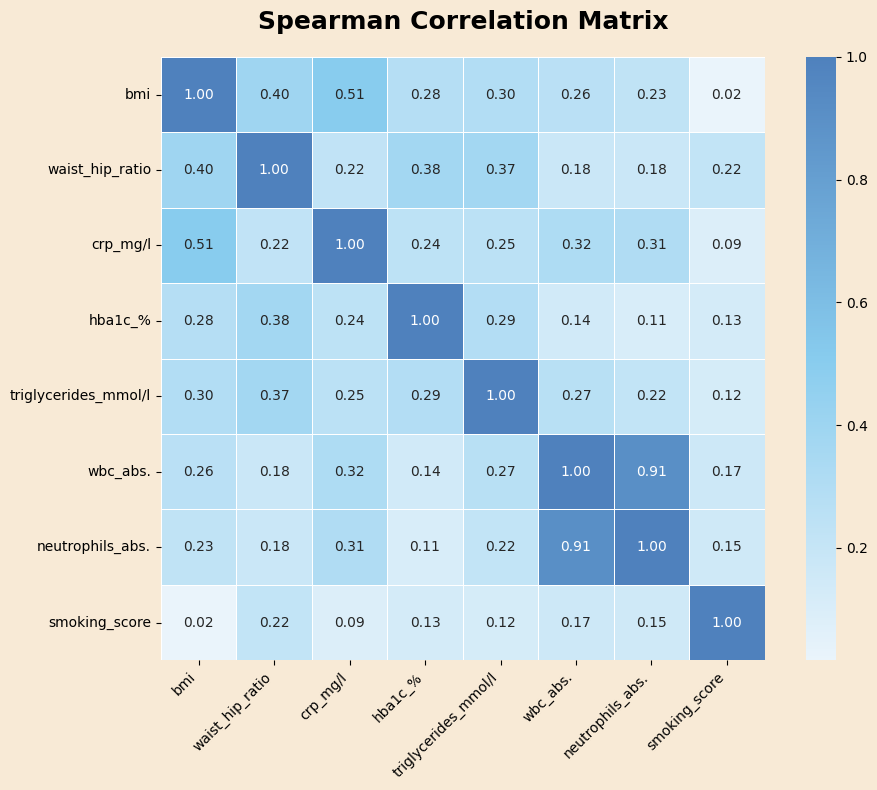

In [39]:
corr = df[vars].corr(method="spearman")

plt.figure(figsize=(10,8))

ax = sns.heatmap(
    corr,
    annot=True,
    cmap=sns.blend_palette(
        ["#EAF4FB", "#88CCEE", "#4F81BD"],
        as_cmap=True
    ),
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title(
    "Spearman Correlation Matrix",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
fig = plt.gcf()
ax = plt.gca()

fig.patch.set_facecolor("#f8ead6")
ax.set_facecolor("#f8ead6")
plt.show()

In [23]:
cluster_vars = [
    "bmi",
    "waist_hip_ratio",
    "crp_mg/l",
    "hba1c_%",
    "triglycerides_mmol/l",
    "wbc_abs.",
    "neutrophils_abs."
]

## Kmeans

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

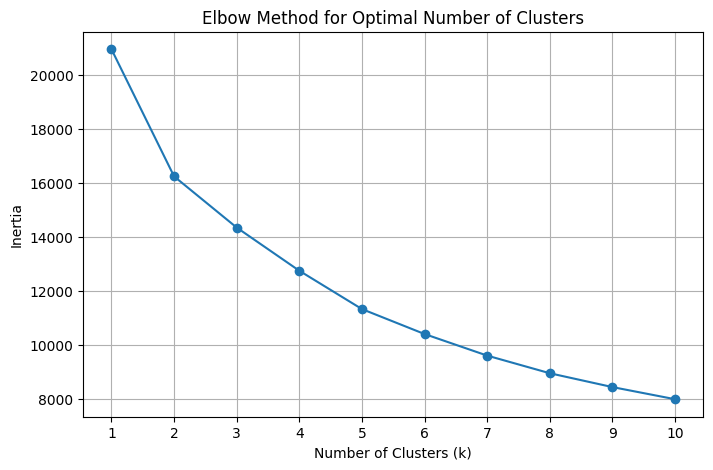

In [32]:

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [33]:
cluster_vars = [
    "bmi",
    "waist_hip_ratio",
    "crp_mg/l",
    "hba1c_%",
    "triglycerides_mmol/l",
    "wbc_abs.",
    "neutrophils_abs."
]

cluster_df = df[cluster_vars].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_df["cluster"].value_counts()

cluster
0    1459
2    1053
1     479
Name: count, dtype: int64

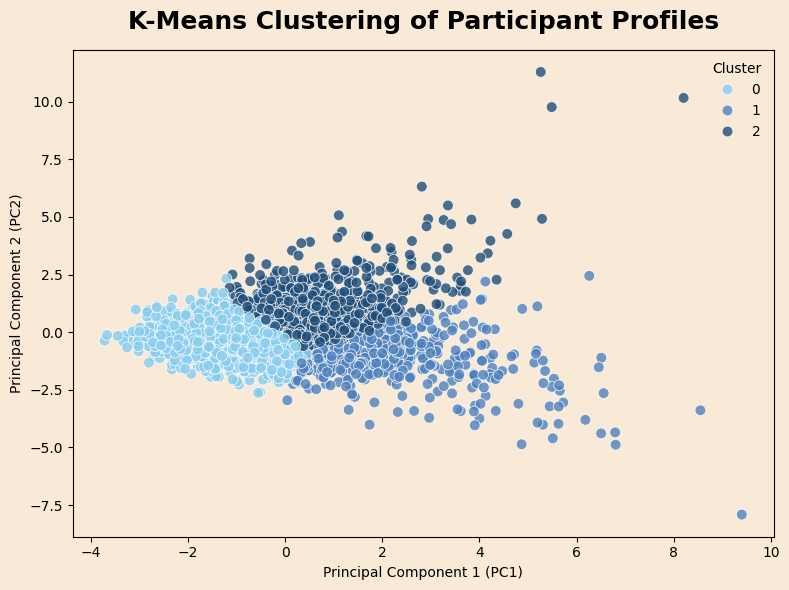

In [45]:
plt.figure(figsize=(8,6))

ax = sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=["#88CCEE", "#4F81BD", "#1F4E79"],
    s=60,
    alpha=0.8
)

ax.set_facecolor("#f8ead6")
plt.gcf().patch.set_facecolor("#f8ead6")

plt.title(
    "K-Means Clustering of Participant Profiles",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

legend = plt.legend(title="Cluster")

legend.get_frame().set_facecolor("#f8ead6")
legend.get_frame().set_edgecolor("none")

plt.tight_layout()
plt.show()

In [35]:
cluster_summary = (
    cluster_df
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_summary

,bmi,waist_hip_ratio,crp_mg/l,hba1c_%,triglycerides_mmol/l,wbc_abs.,neutrophils_abs.,PC1,PC2
cluster,,,,,,,,,
0,25.78,0.88,1.85,5.34,0.99,5.53,3.13,-1.19,-0.27
1,34.22,0.95,9.70,5.74,1.41,9.61,6.39,2.23,-1.16
2,32.34,1.00,3.57,6.29,1.83,6.54,3.81,0.64,0.91


In [ ]:
cluster_vars = [
    "bmi",
    "waist_hip_ratio",
    "crp_mg/l",
    "hba1c_%",
    "triglycerides_mmol/l",
    "wbc_abs.",
    "neutrophils_abs."
]

cluster_df_4 = df[cluster_vars].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df_4)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df_4["cluster"] = kmeans.fit_predict(X_scaled)

cluster_df_4["cluster"].value_counts()

cluster
3    1233
1    1122
2     506
0     130
Name: count, dtype: int64

In [ ]:
cluster_df_4.groupby("cluster").mean().round(2)

,bmi,waist_hip_ratio,crp_mg/l,hba1c_%,triglycerides_mmol/l,wbc_abs.,neutrophils_abs.
cluster,,,,,,,
0,32.16,1.01,4.90,9.39,2.74,7.32,4.39
1,24.87,0.86,1.73,5.31,0.93,5.46,3.08
2,34.83,0.95,9.49,5.71,1.44,9.48,6.26
3,31.10,0.98,3.02,5.75,1.56,6.22,3.61


In [ ]:
cluster_profile = (
    cluster_df
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_profile

,bmi,waist_hip_ratio,crp_mg/l,hba1c_%,triglycerides_mmol/l,wbc_abs.,neutrophils_abs.
cluster,,,,,,,
0,25.78,0.88,1.85,5.34,0.99,5.53,3.13
1,34.22,0.95,9.70,5.74,1.41,9.61,6.39
2,32.34,1.00,3.57,6.29,1.83,6.54,3.81


In [ ]:
cluster_profile_median = (
    cluster_df
    .groupby("cluster")
    .median()
    .round(2)
)

cluster_profile_median

,bmi,waist_hip_ratio,crp_mg/l,hba1c_%,triglycerides_mmol/l,wbc_abs.,neutrophils_abs.
cluster,,,,,,,
0,25.1,0.88,1.08,5.3,0.90,5.5,3.1
1,32.9,0.94,5.73,5.6,1.24,9.2,6.0
2,31.4,1.00,2.40,5.9,1.52,6.5,3.8


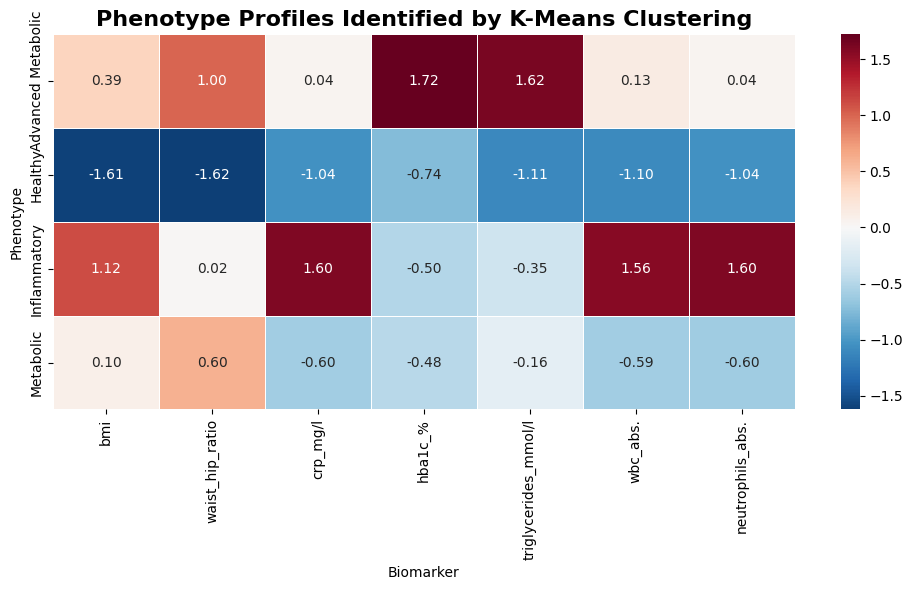

In [ ]:
cluster_means = (
    cluster_df_4
    .groupby("cluster")[cluster_vars]
    .mean()
)

# Standardize cluster means for visualization
scaler = StandardScaler()

cluster_means_z = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

# Rename clusters
cluster_means_z.index = [
    "Advanced Metabolic",
    "Healthy",
    "Inflammatory",
    "Metabolic"
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_means_z,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Phenotype Profiles Identified by K-Means Clustering",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Biomarker")
plt.ylabel("Phenotype")

plt.tight_layout()
plt.show()

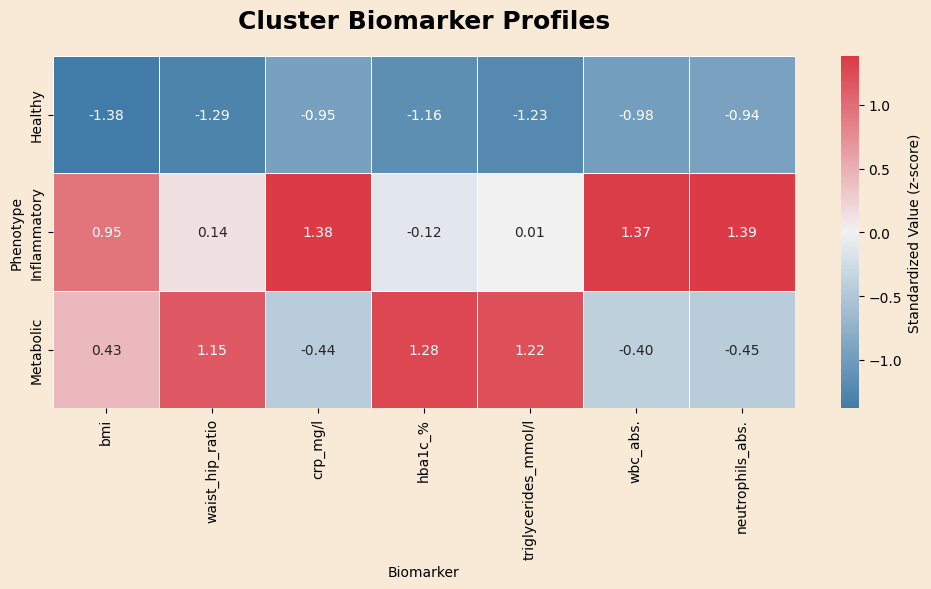

In [48]:
cluster_means = (
    cluster_df
    .groupby("cluster")[cluster_vars]
    .mean()
)

# Standardize cluster means
scaler = StandardScaler()

cluster_means_z = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

cluster_means_z.index = [
    "Healthy",
    "Inflammatory",
    "Metabolic"
]

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    cluster_means_z,
    annot=True,
    cmap=sns.diverging_palette(
        240, 10,
        as_cmap=True
    ),
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Standardized Value (z-score)"}
)

# Presentation styling
ax.set_facecolor("#f8ead6")
plt.gcf().patch.set_facecolor("#f8ead6")

plt.title(
    "Cluster Biomarker Profiles",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Biomarker")
plt.ylabel("Phenotype")

plt.tight_layout()
plt.show()

## PCA Analysis

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_df = df[cluster_vars].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [25]:

import numpy as np
explained_var = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_var

,PC,Explained Variance,Cumulative Variance
0,PC1,0.367455,0.367455
1,PC2,0.193560,0.561015
2,PC3,0.138816,0.699831
3,PC4,0.108466,0.808297
4,PC5,0.098620,0.906916
5,PC6,0.083360,0.990276
6,PC7,0.009724,1.000000


In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(cluster_vars))],
    index=cluster_vars
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
bmi,0.355,0.100,0.575,-0.393,-0.165,-0.592,-0.035
waist_hip_ratio,0.330,0.445,0.046,-0.514,0.018,0.652,0.014
crp_mg/l,0.294,-0.221,0.626,0.556,-0.074,0.398,0.008
hba1c_%,0.268,0.507,-0.037,0.353,0.705,-0.220,-0.011
triglycerides_mmol/l,0.262,0.471,-0.300,0.378,-0.680,-0.115,-0.029
wbc_abs.,0.526,-0.347,-0.297,-0.043,0.049,-0.058,0.712
neutrophils_abs.,0.511,-0.379,-0.310,-0.049,0.075,-0.004,-0.700


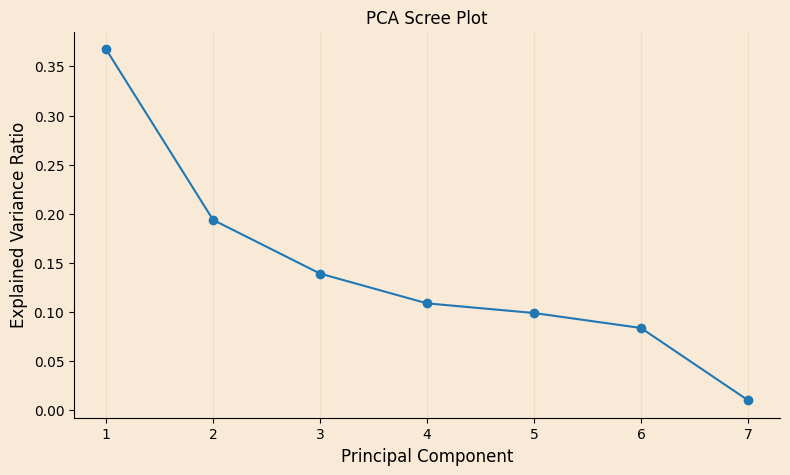

In [27]:

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(cluster_vars))],
    index=cluster_vars
)

loadings.round(3)
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

style_chart(
    title="PCA Scree Plot",
    xlabel="Principal Component",
    ylabel="Explained Variance Ratio",
    grid_axis="x"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")

plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(cluster_vars))],
    index=cluster_vars
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
bmi,0.355,0.100,0.575,-0.393,-0.165,-0.592,-0.035
waist_hip_ratio,0.330,0.445,0.046,-0.514,0.018,0.652,0.014
crp_mg/l,0.294,-0.221,0.626,0.556,-0.074,0.398,0.008
hba1c_%,0.268,0.507,-0.037,0.353,0.705,-0.220,-0.011
triglycerides_mmol/l,0.262,0.471,-0.300,0.378,-0.680,-0.115,-0.029
wbc_abs.,0.526,-0.347,-0.297,-0.043,0.049,-0.058,0.712
neutrophils_abs.,0.511,-0.379,-0.310,-0.049,0.075,-0.004,-0.700


## Predict High CRP logreg, randomForest

In [50]:
df["high_crp"] = (
    df["crp_mg/l"] > 3
).astype(int)

df["high_crp"].value_counts(normalize=True) * 100

high_crp
0    75.027597
1    24.972403
Name: proportion, dtype: float64

In [51]:
df["high_crp_5"] = (
    df["crp_mg/l"] > 5
).astype(int)

df["high_crp_5"].value_counts(normalize=True) * 100

high_crp_5
0    85.453207
1    14.546793
Name: proportion, dtype: float64

In [52]:
df["high_crp_10"] = (
    df["crp_mg/l"] > 10
).astype(int)

df["high_crp_10"].value_counts(normalize=True) * 100

high_crp_10
0    94.885318
1     5.114682
Name: proportion, dtype: float64

In [53]:
df["smoking_status"] = pd.Series(pd.NA, index=df.index, dtype="object")

df.loc[df["smoked_100_cigs?"] == 2, "smoking_status"] = "Never"
df.loc[df["smoker_now?"] == 3, "smoking_status"] = "Former"
df.loc[df["smoker_now?"] == 2, "smoking_status"] = "Current Some Days"
df.loc[df["smoker_now?"] == 1, "smoking_status"] = "Current Every Day"

smoking_score_map = {
    "Never": 0,
    "Former": 1,
    "Current Some Days": 2,
    "Current Every Day": 3
}

df["smoking_score"] = df["smoking_status"].map(smoking_score_map)

df["smoking_score"].value_counts(dropna=False)

smoking_score
0.0    3810
NaN    1825
1.0    1597
3.0     741
2.0     180
Name: count, dtype: int64

In [ ]:


features= [
    "bmi",
    "waist_hip_ratio",
    "hba1c_%",
    "triglycerides_mmol/l",
    "smoking_score",
    "age",
    "gender"
]

In [55]:
model_df = df[
    features + ["high_crp"]
].dropna()

In [90]:
len(model_df)

3007

In [56]:
from sklearn.model_selection import train_test_split

X = model_df[features]
y = model_df["high_crp"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.749
[[358  39]
 [112  93]]
              precision    recall  f1-score   support

           0       0.76      0.90      0.83       397
           1       0.70      0.45      0.55       205

    accuracy                           0.75       602
   macro avg       0.73      0.68      0.69       602
weighted avg       0.74      0.75      0.73       602



In [74]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
0,bmi,0.976428
6,gender,0.366841
4,smoking_score,0.175582
2,hba1c_%,0.146965
1,waist_hip_ratio,0.103817
3,triglycerides_mmol/l,0.073127
5,age,-0.107828


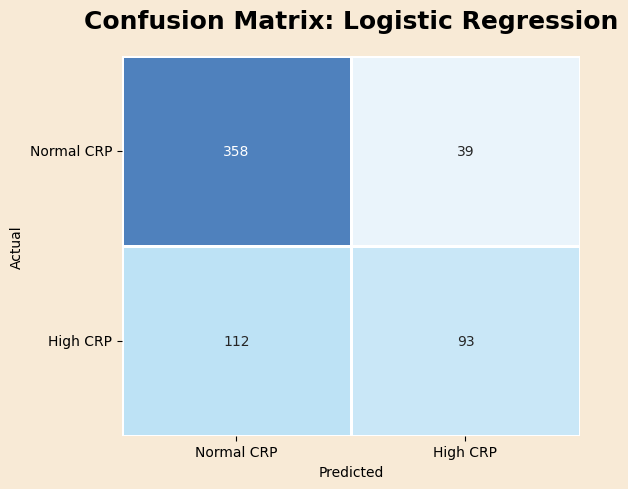

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.blend_palette(
        ["#EAF4FB", "#88CCEE", "#4F81BD"],
        as_cmap=True
    ),
    cbar=False,
    linewidths=1,
    linecolor="white"
)

# Background styling
ax.set_facecolor("#f8ead6")
plt.gcf().patch.set_facecolor("#f8ead6")

# Labels
ax.set_xticklabels(
    ["Normal CRP", "High CRP"],
    rotation=0
)

ax.set_yticklabels(
    ["Normal CRP", "High CRP"],
    rotation=0
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix: Logistic Regression",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [ ]:
df["gender"].value_counts()

gender
2.0    4496
1.0    3657
Name: count, dtype: int64

In [ ]:
df.groupby("gender")["crp_mg/l"].median()

gender
1.0    1.50
2.0    2.16
Name: crp_mg/l, dtype: float64

In [ ]:
df.groupby("gender")["bmi"].median()

gender
1.0    27.9
2.0    28.6
Name: bmi, dtype: float64

In [ ]:
df.groupby("gender")["waist_hip_ratio"].median()

gender
1.0    0.983380
2.0    0.896188
Name: waist_hip_ratio, dtype: float64

In [86]:
features_ext = [
    "bmi",
    "waist_hip_ratio",
    "hba1c_%",
    "triglycerides_mmol/l",
    "smoking_score",
    "age",
    "gender",
    "wbc_abs.",
    "neutrophils_abs."
]

In [87]:
model_df_ext = df[
    features_ext + ["high_crp"]
].dropna()

In [89]:
len(model_df_ext)

2986

In [96]:
X_ext = model_df_ext[features_ext]
y_ext = model_df_ext["high_crp"]

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext,
    y_ext,
    test_size=0.2,
    random_state=42,
    stratify=y_ext
)

scaler_ext = StandardScaler()

X_train_ext_scaled = scaler_ext.fit_transform(X_train_ext)
X_test_ext_scaled = scaler_ext.transform(X_test_ext)

model_ext = LogisticRegression(max_iter=1000)

model_ext.fit(X_train_ext_scaled, y_train_ext)

preds_ext = model_ext.predict(X_test_ext_scaled)

print("Accuracy:", round(accuracy_score(y_test_ext, preds_ext), 3))
print(confusion_matrix(y_test_ext, preds_ext))
print(classification_report(y_test_ext, preds_ext))

coef_df_ext = pd.DataFrame({
    "Variable": features_ext,
    "Coefficient": model_ext.coef_[0]
}).sort_values(
    "Coefficient",
    ascending=False
)

coef_df_ext

Accuracy: 0.758
[[355  40]
 [105  98]]
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       395
           1       0.71      0.48      0.57       203

    accuracy                           0.76       598
   macro avg       0.74      0.69      0.70       598
weighted avg       0.75      0.76      0.74       598



,Variable,Coefficient
0,bmi,0.914923
6,gender,0.320432
7,wbc_abs.,0.312913
8,neutrophils_abs.,0.141708
2,hba1c_%,0.134815
4,smoking_score,0.100249
1,waist_hip_ratio,0.046572
3,triglycerides_mmol/l,0.032809
5,age,-0.004966


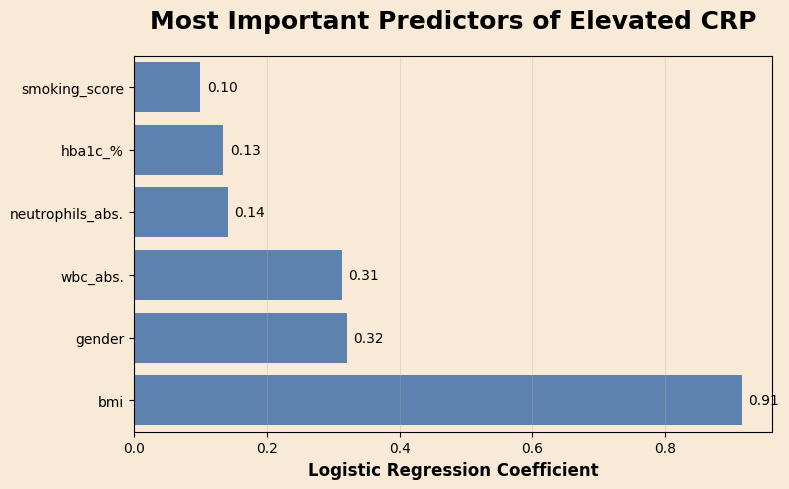

In [106]:
plt.figure(figsize=(8,5))

coef_plot = coef_df_ext.head(6).sort_values(
    "Coefficient",
    ascending=True
)

ax = sns.barplot(
    data=coef_plot,
    x="Coefficient",
    y="Variable",
    color="#4F81BD"
)

# Add coefficient values automatically
for i, v in enumerate(coef_plot["Coefficient"]):
    ax.text(
        v + 0.01,
        i,
        f"{v:.2f}",
        va="center",
        fontsize=10
    )

# Styling
ax.set_facecolor("#f8ead6")
plt.gcf().patch.set_facecolor("#f8ead6")

plt.xlabel(
    "Logistic Regression Coefficient",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel("")

plt.title(
    "Most Important Predictors of Elevated CRP",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

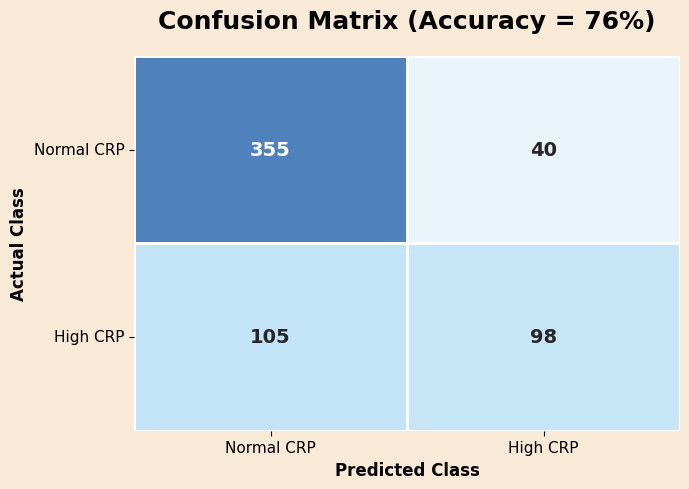

In [101]:
preds = model_ext.predict(X_test_ext_scaled)

cm = confusion_matrix(y_test_ext, preds)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.blend_palette(
        ["#EAF4FB", "#88CCEE", "#4F81BD"],
        as_cmap=True
    ),
    cbar=False,
    linewidths=1,
    linecolor="white",
    annot_kws={
        "fontsize": 14,
        "fontweight": "bold"
    }
)

# Background styling
ax.set_facecolor("#f8ead6")
plt.gcf().patch.set_facecolor("#f8ead6")

# Labels
ax.set_xticklabels(
    ["Normal CRP", "High CRP"],
    fontsize=11
)

ax.set_yticklabels(
    ["Normal CRP", "High CRP"],
    fontsize=11,
    rotation=0
)

plt.xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Confusion Matrix (Accuracy = 76%)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [91]:
coef_df

,Variable,Coefficient
0,bmi,0.976428
6,gender,0.366841
4,smoking_score,0.175582
2,hba1c_%,0.146965
1,waist_hip_ratio,0.103817
3,triglycerides_mmol/l,0.073127
5,age,-0.107828


In [92]:
coef_df_ext

NameError: name 'coef_df_ext' is not defined

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
rf_preds = rf.predict(X_test)

In [ ]:


print(
    "Accuracy:",
    round(
        accuracy_score(y_test, rf_preds),
        3
    )
)

print(confusion_matrix(
    y_test,
    rf_preds
))

print(classification_report(
    y_test,
    rf_preds
))

Accuracy: 0.713
[[339  58]
 [115  90]]
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       397
           1       0.61      0.44      0.51       205

    accuracy                           0.71       602
   macro avg       0.68      0.65      0.65       602
weighted avg       0.70      0.71      0.70       602



In [ ]:
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
})

importance_df.sort_values(
    "Importance",
    ascending=False
)

,Variable,Importance
0,bmi,0.308406
1,waist_hip_ratio,0.179958
3,triglycerides_mmol/l,0.170644
5,age,0.147582
2,hba1c_%,0.127528
4,smoking_score,0.040584
6,gender,0.025297


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = coef_df.sort_values("Coefficient")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="Coefficient",
    y="Variable"
)

style_chart(
    title="Predictors of Elevated Inflammation (CRP > 3 mg/L)",
    xlabel="Standardized Logistic Regression Coefficient",
    ylabel=""
)

plt.show()

NameError: name 'coef_df' is not defined

In [ ]:
print(plt)

<module 'matplotlib.pyplot' from '/Users/hughesy/Documents/FinalProject/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>
